 # Classifier Evaluation

In [2]:
import sys
import yaml
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Any
from IPython.display import display
from torch.utils.data import DataLoader
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_fscore_support

PROJECT_ROOT = Path("..")
sys.path.insert(0, str(PROJECT_ROOT / "src/classifier"))

from dataset import BrailleMultiLabelDataset, get_transforms
from model import BrailleDotNet
from metrics import compute_metrics

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110})

palette = {"train": "#4C72B0", "val": "#DD8452", "test": "#55A868"}
dot_labels = ["1", "2", "3", "4", "5", "6"]

def load_yaml(path: Path) -> dict[str, Any]:
    with path.open(encoding="utf-8") as f:
        return yaml.safe_load(f)

cls_cfg = load_yaml(PROJECT_ROOT / "configs/classifier_config.yaml")
global_data_cfg = load_yaml(PROJECT_ROOT / "configs/data_config.yaml")

domain_map = {
    key.upper(): val["name"] 
    for key, val in global_data_cfg["datasets"].items() 
    if key != "merged"
}
domain_prefixes = {
    val["name"]: val["prefix"] 
    for key, val in global_data_cfg["datasets"].items() 
    if key != "merged" and "prefix" in val
}

paths_cfg = cls_cfg["paths"]
train_cfg = cls_cfg["training"]
cls_data_cfg = cls_cfg["data_processing"]

exp_dir = PROJECT_ROOT / paths_cfg["project_dir"] / paths_cfg["experiment_name"]
dataset_dir = PROJECT_ROOT / paths_cfg["crops_dir"]
weights_path = exp_dir / paths_cfg["best_model_name"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BrailleDotNet(num_classes=cls_cfg["model"]["num_classes"], in_channels=cls_cfg["model"]["in_channels"])
model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
model.to(device).eval()

threshold = train_cfg["threshold"]
batch_size = train_cfg["batch_size"]
num_workers = cls_data_cfg["num_workers"]

val_transforms = get_transforms(cls_data_cfg["mean"], cls_data_cfg["std"], is_train=False)


In [3]:
def bits_to_braille(bits: np.ndarray) -> str:
    return "".join(str(i + 1) for i, b in enumerate(bits) if b == 1) or "0"

def get_domain(path: Path) -> str:
    for name, prefix in domain_prefixes.items():
        if path.name.startswith(prefix):
            return name
    return "Unknown"

def build_dataloader(split: str) -> tuple[BrailleMultiLabelDataset, DataLoader]:
    ds = BrailleMultiLabelDataset(
        data_dir=dataset_dir / split, transforms=val_transforms, cache_in_ram=False
    )
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return ds, dl

@torch.no_grad()
def run_inference(dataloader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    all_targets, all_preds = [], []
    for images, targets in dataloader:
        logits = model(images.to(device, non_blocking=True))
        all_preds.append((logits > threshold).float().cpu().numpy())
        all_targets.append(targets.numpy())
    return np.vstack(all_targets), np.vstack(all_preds)

def show_domain_metrics(y_true: np.ndarray, y_pred: np.ndarray, domains: np.ndarray, split: str) -> None:
    rows = {"Overall": compute_metrics(y_true, y_pred)}
    for label in domain_map.values():
        if (mask := (domains == label)).any():
            rows[label] = compute_metrics(y_true[mask], y_pred[mask])

    df = pd.DataFrame(rows).T
    display(
        df[["CharAccuracy", "CharPrecision", "CharRecall", "CharF1"]]
        .style.format("{:.4f}")
        .set_caption(f"{split.upper()} — Character-Level Metrics")
    )
    display(
        df[["DotAccuracy"]]
        .style.format("{:.4f}")
        .set_caption(f"{split.upper()} — Dot-Level Accuracy")
    )

def show_eval_plots(y_true: np.ndarray, y_pred: np.ndarray, split: str) -> None:
    fig, axes = plt.subplots(1, 6, figsize=(18, 3))
    for dot_idx, (ax, dot_label) in enumerate(zip(np.atleast_1d(axes), dot_labels)):
        ax.grid(False)
        ConfusionMatrixDisplay.from_predictions(
            y_true[:, dot_idx], y_pred[:, dot_idx], ax=ax, colorbar=False, cmap="Blues", display_labels=["0", "1"]
        )
        ax.set_title(f"Dot {dot_label}", fontsize=9)
        
    fig.suptitle(f"Per-Dot Confusion Matrices — {split.upper()}", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

def show_sample_preds(
    ds: BrailleMultiLabelDataset, y_true: np.ndarray, y_pred: np.ndarray,
    indices: np.ndarray, split_label: str = "", n: int = 8
) -> None:
    wrong = indices[~np.all(y_true[indices] == y_pred[indices], axis=1)]
    if len(wrong) == 0:
        return

    err_counts = np.sum(y_true[wrong] != y_pred[wrong], axis=1)
    top_idx = wrong[np.argsort(err_counts)[::-1][:n]]

    fig, axes = plt.subplots(1, len(top_idx), figsize=(2.5 * len(top_idx), 3.5))
    for ax, idx in zip(np.atleast_1d(axes), top_idx):
        ax.imshow(plt.imread(str(ds.image_paths[idx])), cmap="gray")
        ax.axis("off")
        ax.set_title(
            f"GT:   {bits_to_braille(y_true[idx])}\nPred: {bits_to_braille(y_pred[idx])}",
            fontsize=8, fontfamily="monospace"
        )

    if split_label:
        fig.suptitle(f"Worst Errors [{split_label}]", fontsize=10, fontweight="bold")
    plt.tight_layout()
    plt.show()

def dot_metrics_table(y_true: np.ndarray, y_pred: np.ndarray, domains: np.ndarray, split: str) -> None:
    groups = {"Overall": np.ones(len(domains), dtype=bool)} | {
        label: domains == label for label in domain_map.values()
    }

    rows = []
    for name, mask in groups.items():
        if not mask.any():
            continue
        for dot_idx, dot_label in enumerate(dot_labels):
            p, r, f1, _ = precision_recall_fscore_support(
                y_true[mask, dot_idx].astype(int),
                y_pred[mask, dot_idx].astype(int),
                average="macro", zero_division=0
            )
            rows.append({
                "Domain": name, "Dot": f"Dot {dot_label}",
                "Precision": float(p), "Recall": float(r), "F1": float(f1)
            })

    df = pd.DataFrame(rows).set_index(["Domain", "Dot"])
    
    styled_df = (
        df.style.format("{:.4f}")
        .set_caption(f"{split.upper()} — Per-Dot Metrics by Domain")
        .set_table_styles([
            {'selector': 'th.level0', 'props': [('border-top', '2px solid #555'), ('vertical-align', 'top')]},
            {'selector': 'td.level0', 'props': [('border-top', '2px solid #555')]}
        ], overwrite=False)
    )
    display(styled_df)


 ---

 ## 1. Training Summary

,value
parameter,
epochs,35
batch_size,512
learning_rate,0.005
weight_decay,1e-4
patience,15
threshold,0.0
seed,42


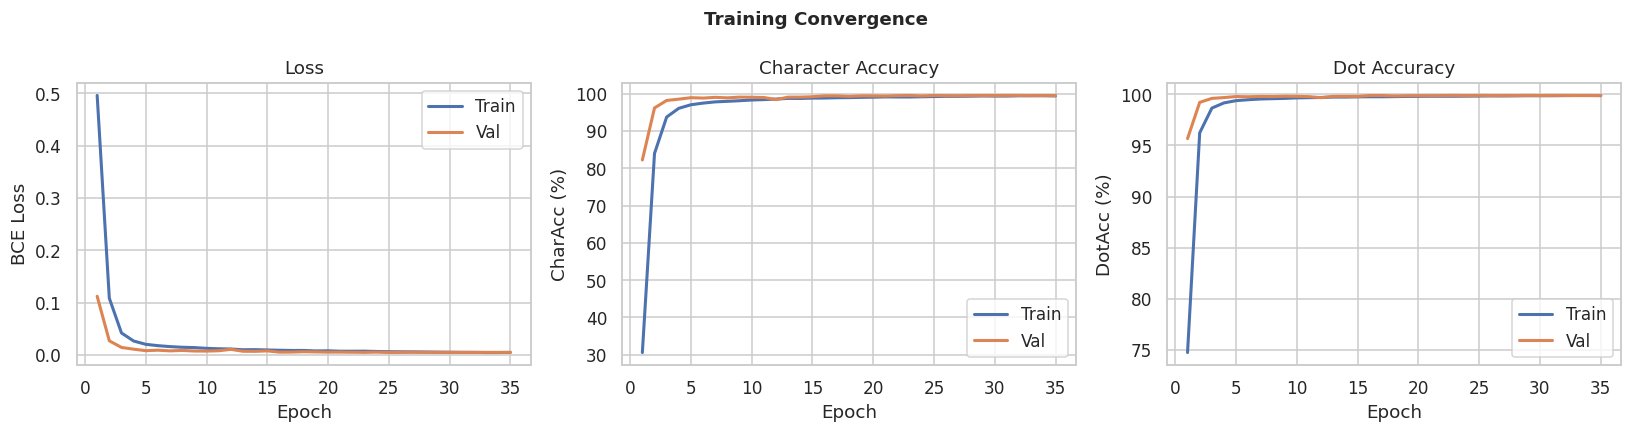

In [4]:
hparam_keys = ["epochs", "batch_size", "learning_rate", "weight_decay", "patience", "threshold", "seed"]
display(pd.DataFrame([(k, train_cfg.get(k, "—")) for k in hparam_keys], columns=["parameter", "value"]).set_index("parameter"))

log_csv = exp_dir / "train_log.csv"
if log_csv.exists():
    df_log = pd.read_csv(log_csv)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(df_log["epoch"], df_log["train_loss"], label="Train", color=palette["train"], lw=2)
    axes[0].plot(df_log["epoch"], df_log["val_loss"], label="Val", color=palette["val"], lw=2)
    axes[0].set(title="Loss", xlabel="Epoch", ylabel="BCE Loss")
    axes[0].legend()

    axes[1].plot(df_log["epoch"], df_log["train_CharAccuracy"] * 100, label="Train", color=palette["train"], lw=2)
    axes[1].plot(df_log["epoch"], df_log["val_CharAccuracy"] * 100, label="Val", color=palette["val"], lw=2)
    axes[1].set(title="Character Accuracy", xlabel="Epoch", ylabel="CharAcc (%)")
    axes[1].legend()

    axes[2].plot(df_log["epoch"], df_log["train_DotAccuracy"] * 100, label="Train", color=palette["train"], lw=2)
    axes[2].plot(df_log["epoch"], df_log["val_DotAccuracy"] * 100, label="Val", color=palette["val"], lw=2)
    axes[2].set(title="Dot Accuracy", xlabel="Epoch", ylabel="DotAcc (%)")
    axes[2].legend()

    fig.suptitle("Training Convergence", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


 ---

 ## 2. Evaluation

 ### 2a. Validation set

In [5]:
ds_val, dl_val = build_dataloader("val")
y_true_val, y_pred_val = run_inference(dl_val)
domains_val = np.array([get_domain(p) for p in ds_val.image_paths])

show_domain_metrics(y_true_val, y_pred_val, domains_val, "val")


,CharAccuracy,CharPrecision,CharRecall,CharF1
Overall,0.9952,0.9864,0.9869,0.9864
Angelina,0.9989,0.9430,0.9407,0.9418
NaturalScene,0.9416,0.8554,0.8627,0.8472
DSBI,0.9937,0.9753,0.9768,0.9758


,DotAccuracy
Overall,0.9989
Angelina,0.9998
NaturalScene,0.9849
DSBI,0.9989


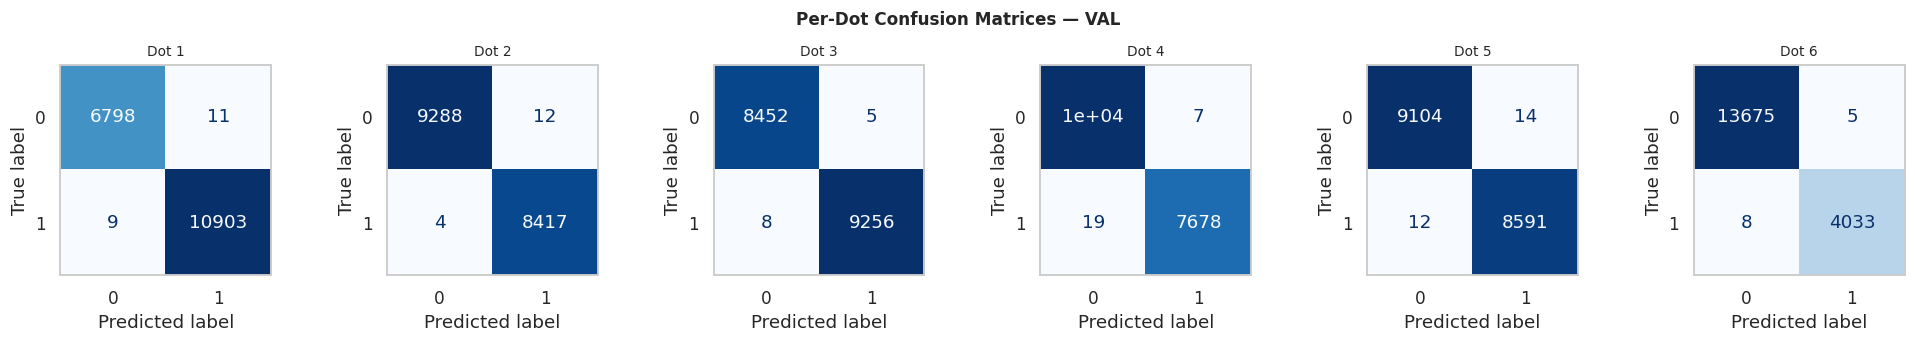

In [6]:
show_eval_plots(y_true_val, y_pred_val, "val")


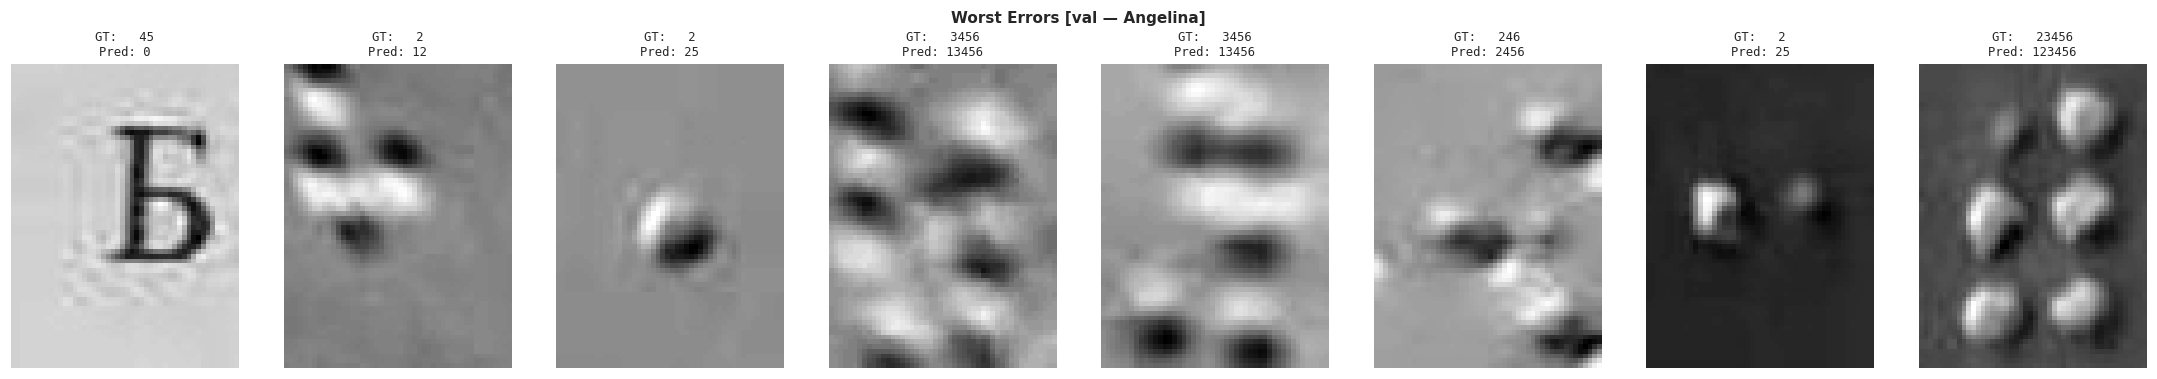

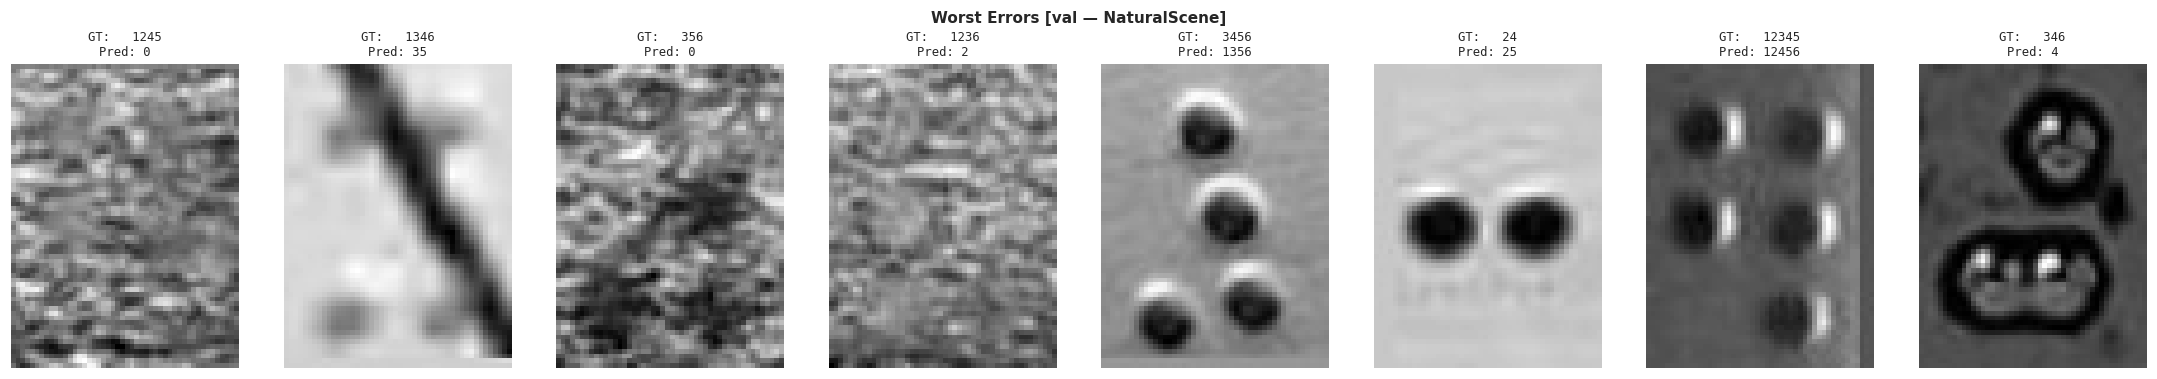

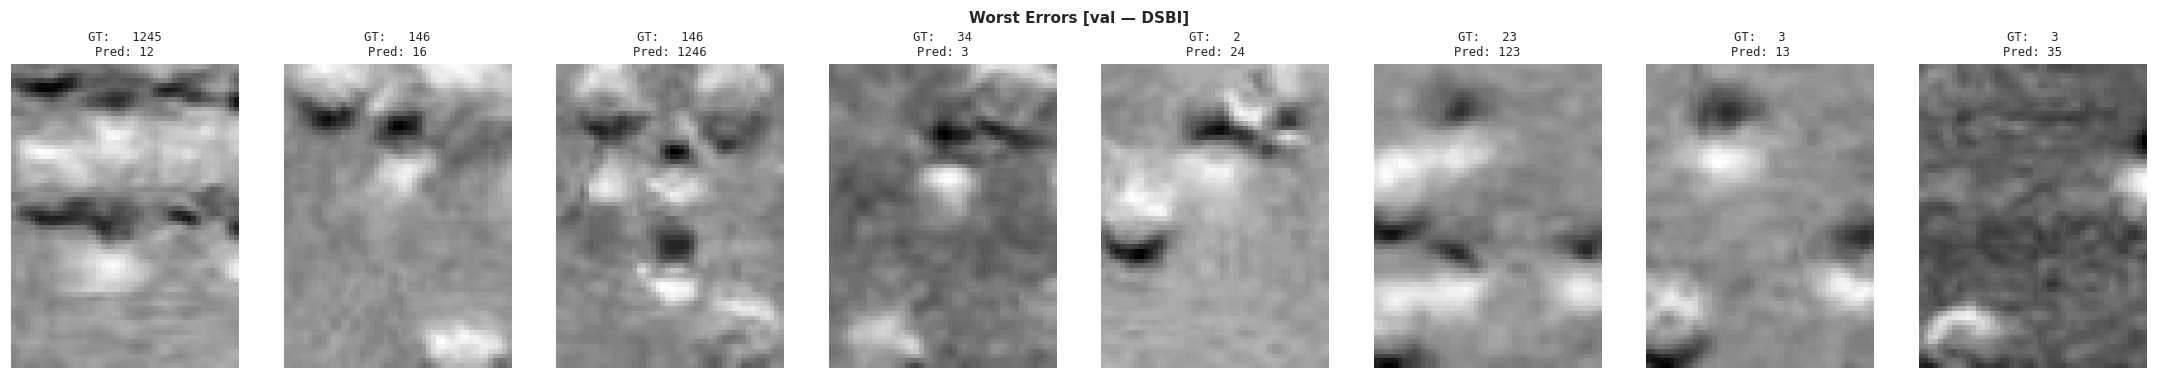

In [7]:
for label in domain_map.values():
    if len(indices := np.where(domains_val == label)[0]):
        show_sample_preds(ds_val, y_true_val, y_pred_val, indices, split_label=f"val — {label}")


 ### 2b. Test set

In [8]:
ds_test, dl_test = build_dataloader("test")
y_true_test, y_pred_test = run_inference(dl_test)
domains_test = np.array([get_domain(p) for p in ds_test.image_paths])

show_domain_metrics(y_true_test, y_pred_test, domains_test, "test")


,CharAccuracy,CharPrecision,CharRecall,CharF1
Overall,0.9843,0.9783,0.9781,0.9780
Angelina,0.9406,0.8279,0.8851,0.8340
NaturalScene,0.9540,0.9102,0.9122,0.9034
DSBI,0.9960,0.9769,0.9785,0.9777


,DotAccuracy
Overall,0.9960
Angelina,0.9835
NaturalScene,0.9862
DSBI,0.9993


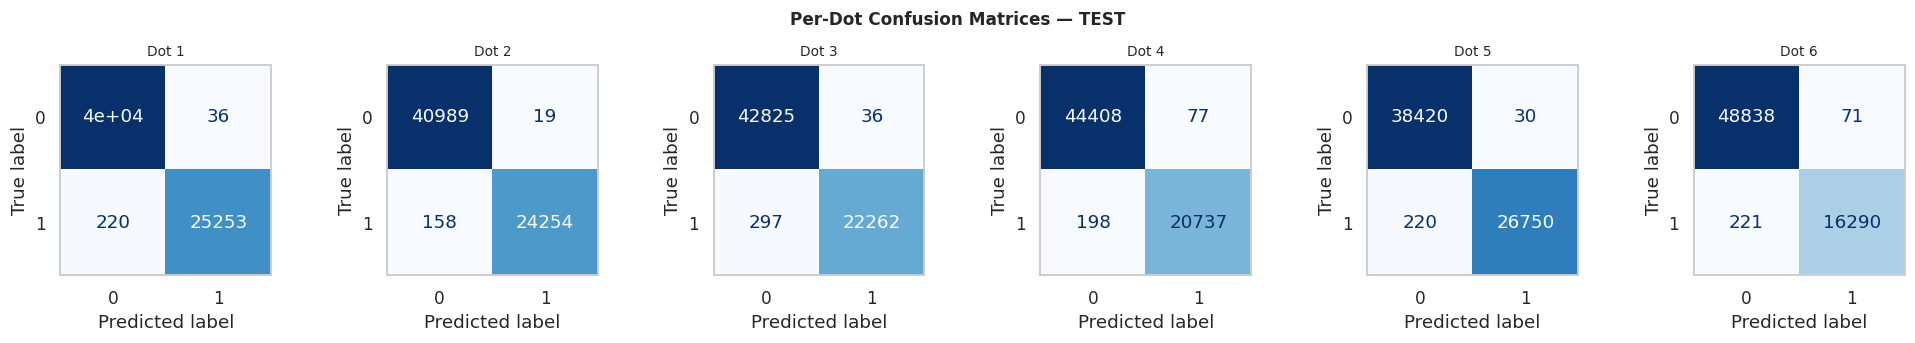

In [9]:
show_eval_plots(y_true_test, y_pred_test, "test")


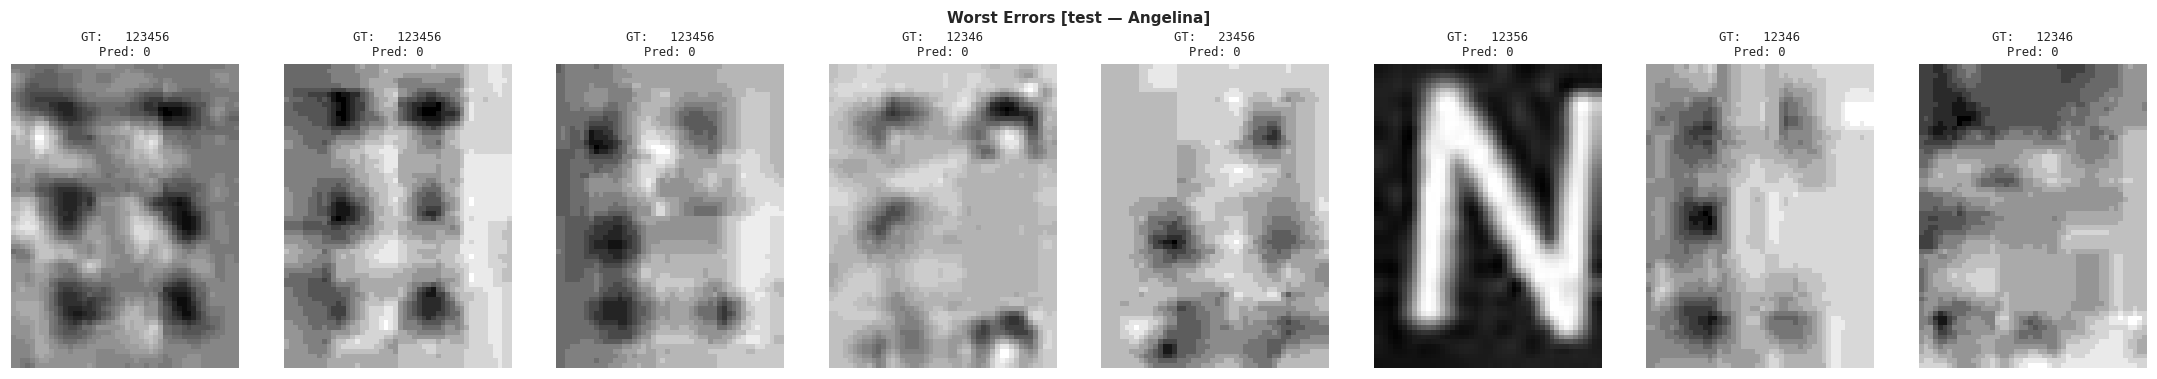

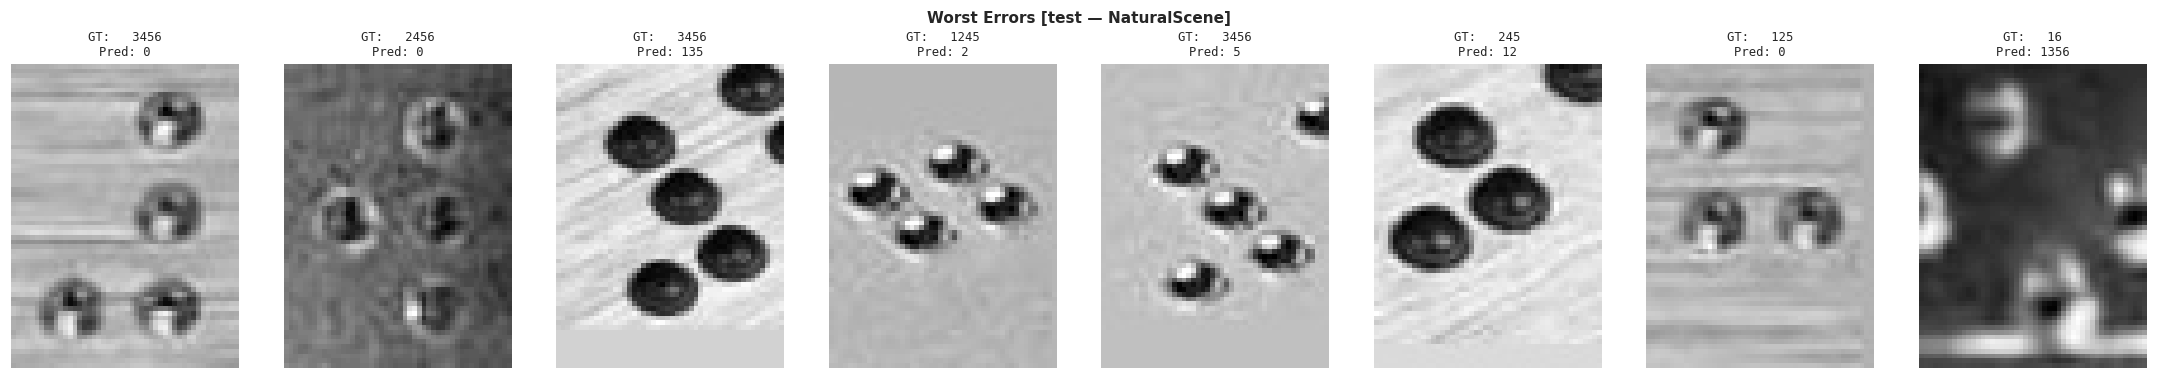

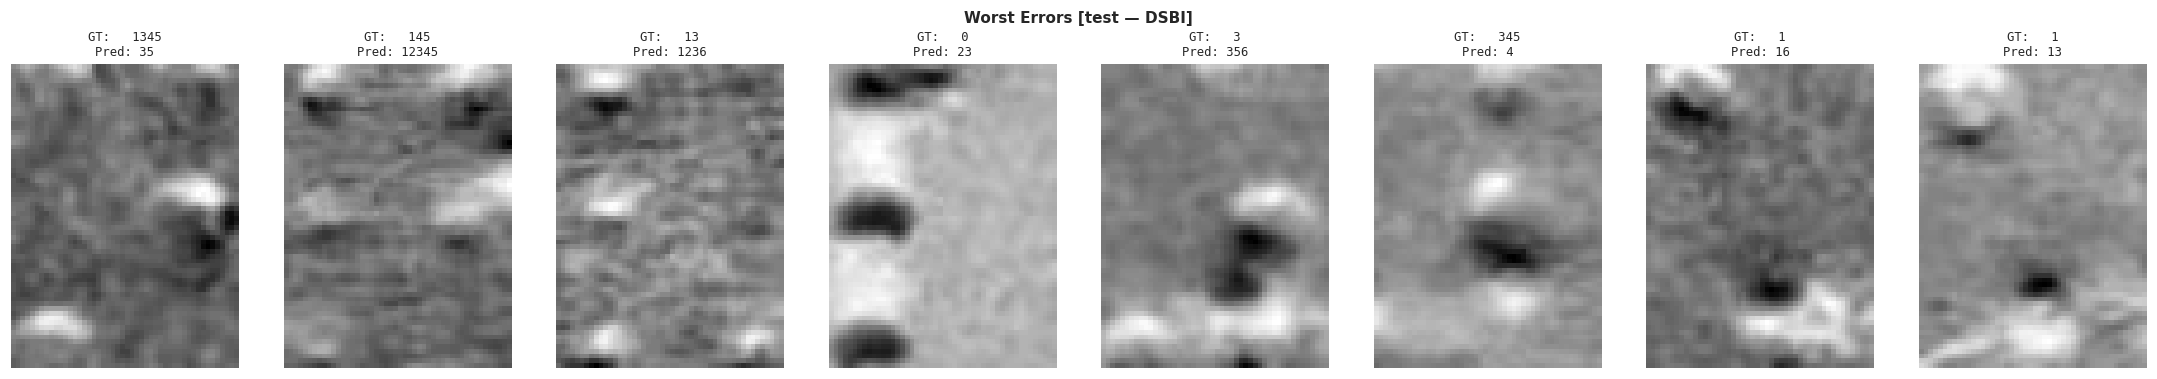

In [10]:
for label in domain_map.values():
    if len(indices := np.where(domains_test == label)[0]):
        show_sample_preds(ds_test, y_true_test, y_pred_test, indices, split_label=f"test — {label}")


 ---

 ## 3. Error Analysis

In [11]:
dot_metrics_table(y_true_val, y_pred_val, domains_val, "val")
dot_metrics_table(y_true_test, y_pred_test, domains_test, "test")